## 1. 릿지 (Ridge)

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


In [2]:
from sklearn.linear_model import Ridge
import numpy as np

# alpha를 로그 스케일로 5단계 설정하기
# [0.01, 0.1, 1, 10, 100]
alpha = np.logspace(-2, 2, 5)

np.set_printoptions(suppress=True) #numpy의 출력 형식 변경(일반 숫자로 설정)
alpha

array([  0.01,   0.1 ,   1.  ,  10.  , 100.  ])

In [3]:
data = []
for a in alpha:
    ridge = Ridge(alpha=a, random_state=45)
    ridge.fit(X, y)
    data.append(pd.Series(ridge.coef_)) #가중치 추출

df_ridge = pd.DataFrame(data, index=alpha)
df_ridge.columns = X.columns
df_ridge

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.01,-7.199457,-234.552930,520.583136,320.523356,-380.607066,150.483752,-78.591232,130.313059,592.349587,71.133768
0.10,1.307349,-207.194814,489.691080,301.769437,-83.466074,-70.828096,-188.680164,115.712703,443.814054,86.748539
1.00,29.465746,-83.154885,306.351627,201.629434,5.909369,-29.515927,-152.040465,117.311715,262.944995,111.878718
10.00,19.812822,-0.918458,75.416167,55.025419,19.924600,13.948686,-47.553816,48.259420,70.144068,44.213876
100.00,2.897090,0.585254,9.240719,6.931321,3.230957,2.616766,-6.174550,6.678027,8.876864,5.955597


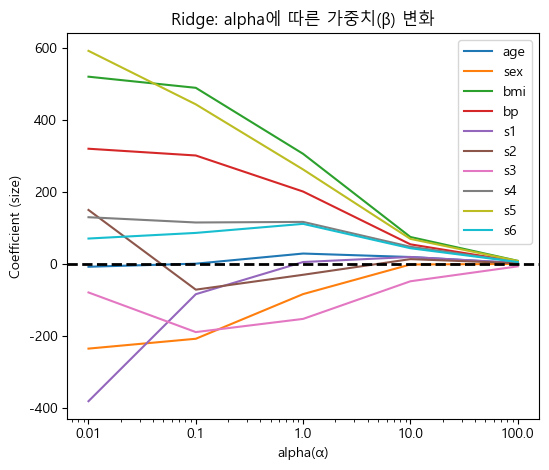

In [5]:
import matplotlib.pyplot as plt

plt.semilogx(df_ridge)
plt.xticks(alpha, labels=[str(round(a, 3)) for a in alpha])
plt.legend(labels=df_ridge.columns, bbox_to_anchor=(1, 1))
plt.axhline(y=0, linestyle='--', color='black', linewidth=2)

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
plt.title('Ridge: alpha에 따른 가중치(β) 변화')
plt.xlabel('alpha(α)')
plt.ylabel('Coefficient (size)')
plt.tight_layout()
plt.show()

## 2. 라쏘 (Lasso)

In [6]:
from sklearn.linear_model import Lasso
import numpy as np

data_lasso = []
for a in alpha:
    lasso = Lasso(alpha=a, random_state=45)
    lasso.fit(X, y)
    data_lasso.append(pd.Series(lasso.coef_))

df_lasso = pd.DataFrame(data_lasso, index=alpha)
df_lasso.columns = X.columns
df_lasso

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.01,-1.306575,-228.822331,525.560658,316.175320,-307.013677,89.321688,-105.081398,119.597989,571.330871,65.007316
0.10,-0.000000,-155.362882,517.182017,275.082351,-52.540269,-0.000000,-210.159753,0.000000,483.914409,33.672821
1.00,0.000000,-0.000000,367.701852,6.301904,0.000000,0.000000,-0.000000,0.000000,307.605700,0.000000
10.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


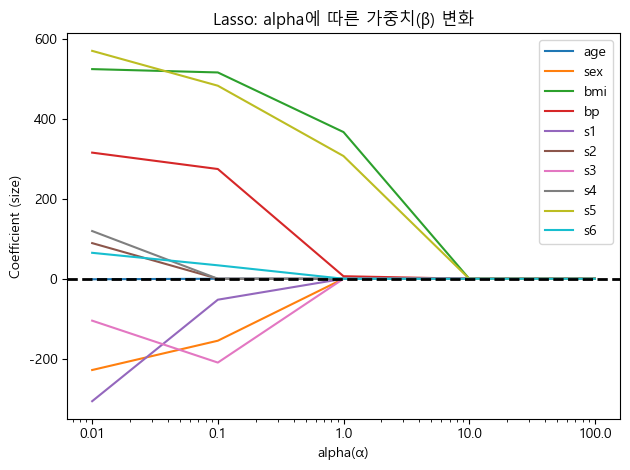

In [7]:
plt.semilogx(df_lasso)
plt.xticks(alpha, labels=[str(round(a, 3)) for a in alpha])
plt.legend(labels=df_lasso.columns, bbox_to_anchor=(1, 1))
plt.axhline(y=0, linestyle='--', color='black', linewidth=2)

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
plt.title('Lasso: alpha에 따른 가중치(β) 변화')
plt.xlabel('alpha(α)')
plt.ylabel('Coefficient (size)')
plt.tight_layout()
plt.show()

## 3. 엘라스틱넷 (ElasticNet)

In [8]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
import numpy as np

# 단일 모델 학습
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=45)
enet.fit(X, y)

data_enet = pd.Series(enet.coef_)
df_enet = pd.DataFrame(data_enet).T
df_enet.columns = X.columns
df_enet

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,10.286327,0.285976,37.464643,27.544899,11.10885,8.355884,-24.120808,25.505488,35.465757,22.894981


In [9]:
# CV로 최적 하이퍼파라미터 자동 탐색
enet_cv = ElasticNetCV(
    l1_ratio=[0.3, 0.5, 0.7, 0.9, 1.0],
    alphas=alpha,
    cv=5,
    random_state=45
)
enet_cv.fit(X, y)
print('최적 alpha  :', round(enet_cv.alpha_, 4))
print('최적 l1_ratio:', enet_cv.l1_ratio_)

data_enet_cv = pd.Series(enet_cv.coef_)
df_enet_cv = pd.DataFrame(data_enet_cv).T
df_enet_cv.columns = X.columns
df_enet_cv

최적 alpha  : 0.01
최적 l1_ratio: 1.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,-1.306575,-228.822331,525.560658,316.17532,-307.013677,89.321688,-105.081398,119.597989,571.330871,65.007316
